# EF ASD EEG preprocessing and trial cutting

This notebook reconstructs and preprocesses the **Emotional Face Go/Nogo (EF)** EEG trials described in the thesis.

### Thesis-based settings used here
- Raw format: Neuroscan `.cnt`
- Sampling rate in the thesis: 1000 Hz
- Band-pass filter: **0.05–30 Hz**
- Epoch: **−200 ms to +1000 ms** relative to emotional-face onset
- Baseline: **−200 to 0 ms**
- Incorrect behavioral trials are excluded from the ERP analysis
- EEG epochs exceeding **±100 µV** are rejected
- Main conditions: **Go/Nogo × Emotion**
- ERP windows used later in the thesis:
  - N170: 160–250 ms
  - N2: 300–400 ms
  - P3/LPP: 500–700 ms
  - Late LPP: 700–1000 ms

### Trigger definitions supplied for this dataset
Stimulus triggers:
- `11` = Go Happy
- `12` = Go Angry
- `13` = Go Surprise
- `14` = Go Neutral
- `51` = Nogo Happy
- `52` = Nogo Angry
- `53` = Nogo Surprise
- `54` = Nogo Neutral

Outcome triggers:
- `101` = correct press
- `69` = missed press when response was required
- `44` = wrong press
- `77` = correct no-response

Extra triggers `255` and `3` are preserved in the raw event stream but ignored during basic trial reconstruction until their role is confirmed.

> Important: the thesis used a Neuroscan eye-correction procedure ("mathematically constructed eye model"). This notebook does **not** silently replace that with ICA. The trial cutting and artifact-rejection steps below can be used as-is; ocular correction can be inserted later if needed.


## 1. Imports

In [2085]:
from pathlib import Path
import glob
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne

print("MNE version:", mne.__version__)


MNE version: 1.8.0


## 2. Set file paths

In [2086]:
# EDIT THESE PATHS

data_path = r'H:\ASD projoect\EF\TD'
data_name = r'2371_RF_CV.cnt'

# Folder used for processed output
output_dir = os.path.join(data_path, data_name.replace('.cnt', '_processed_numpy'))
os.makedirs(output_dir, exist_ok=True)

pattern = os.path.join(data_path, data_name)
files = sorted(glob.glob(pattern))

print("Search pattern:", pattern)
print(f"Found {len(files)} matching CNT file(s):")
for f in files:
    print("  ", f)

if len(files) == 0:
    raise FileNotFoundError(f"No CNT file matched: {pattern}")

# For now use the first matching file.
cnt_file = files[0]
print("\nUsing:", cnt_file)


Search pattern: H:\ASD projoect\EF\TD\2371_RF_CV.cnt
Found 1 matching CNT file(s):
   H:\ASD projoect\EF\TD\2371_RF_CV.cnt

Using: H:\ASD projoect\EF\TD\2371_RF_CV.cnt


## 3. Read the CNT file

In [2087]:
raw = mne.io.read_raw_cnt(
    cnt_file,
    preload=True
)

print(raw)
print("\nSampling rate:", raw.info["sfreq"])
print("Number of channels:", len(raw.ch_names))
print("Duration (s):", raw.times[-1])


Reading 0 ... 1738299  =      0.000 ...  1738.299 secs...


C:\Users\jzwht\AppData\Local\Temp\ipykernel_22824\148782352.py:1: RuntimeWarning:   Could not parse meas date from the header. Setting to None.
  raw = mne.io.read_raw_cnt(


<RawCNT | 2371_RF_CV.cnt, 65 x 1738300 (1738.3 s), ~862.1 MB, data loaded>

Sampling rate: 1000.0
Number of channels: 65
Duration (s): 1738.299


## 4. Inspect channel names and annotations

In [2088]:
print("Channels:")
print(raw.ch_names)

print("\nAnnotations:")
print(raw.annotations)


Channels:
['FP1', 'FPZ', 'FP2', 'AF3', 'AF4', 'F7', 'F5', 'F3', 'F1', 'FZ', 'F2', 'F4', 'F6', 'F8', 'FT7', 'FC5', 'FC3', 'FC1', 'FCZ', 'FC2', 'FC4', 'FC6', 'FT8', 'T7', 'C5', 'C3', 'C1', 'CZ', 'C2', 'C4', 'C6', 'T8', 'M1', 'TP7', 'CP5', 'CP3', 'CP1', 'CPZ', 'CP2', 'CP4', 'CP6', 'TP8', 'M2', 'P7', 'P5', 'P3', 'P1', 'PZ', 'P2', 'P4', 'P6', 'P8', 'PO7', 'PO5', 'PO3', 'POZ', 'PO4', 'PO6', 'PO8', 'O1', 'OZ', 'O2', 'HEO', 'VEO', 'Trigger']

Annotations:
<Annotations | 1053 segments: 101 (320), 11 (84), 12 (84), 13 (84), 14 ...>


## 5. Convert annotations to events using the original trigger numbers

By default, `mne.events_from_annotations()` may map annotation strings to arbitrary integers.  
Here we explicitly preserve the experimental trigger values so that `events[:, 2]` contains values such as `11`, `51`, `101`, etc.


In [2089]:
trigger_codes = [
    11, 12, 13, 14,
    51, 52, 53, 54,
    101, 69, 44, 77,
    255, 3
]

event_id_true = {str(code): code for code in trigger_codes}

events, event_id = mne.events_from_annotations(
    raw,
    event_id=event_id_true
)

print("event_id:")
print(event_id)

print("\nFirst 30 events:")
print(events[:30])


Used Annotations descriptions: ['101', '11', '12', '13', '14', '255', '3', '44', '51', '52', '53', '54', '69', '77']
event_id:
{'101': 101, '11': 11, '12': 12, '13': 13, '14': 14, '255': 255, '3': 3, '44': 44, '51': 51, '52': 52, '53': 53, '54': 54, '69': 69, '77': 77}

First 30 events:
[[29999     0   255]
 [30000     0   255]
 [51400     0    14]
 [52749     0   101]
 [53766     0    14]
 [54932     0   101]
 [55650     0    53]
 [56766     0    77]
 [57583     0    14]
 [57819     0     3]
 [58332     0   101]
 [58950     0    14]
 [59966     0   101]
 [60983     0    14]
 [61982     0   101]
 [63000     0    14]
 [64282     0   101]
 [65100     0    14]
 [66216     0   101]
 [67033     0    14]
 [68216     0   101]
 [69033     0    14]
 [70149     0   101]
 [70867     0    52]
 [72082     0    44]
 [72800     0    14]
 [73682     0   101]
 [74400     0    14]
 [75616     0   101]
 [76233     0    14]]


## 6. Inspect the event sequence

In [2090]:
sfreq = raw.info["sfreq"]

n_show = min(80, len(events))

for k, event in enumerate(events[:n_show]):
    sample = int(event[0])
    code = int(event[2])
    time_s = sample / sfreq
    print(f"{k:03d} | {time_s:10.3f} s | trigger = {code}")


000 |     29.999 s | trigger = 255
001 |     30.000 s | trigger = 255
002 |     51.400 s | trigger = 14
003 |     52.749 s | trigger = 101
004 |     53.766 s | trigger = 14
005 |     54.932 s | trigger = 101
006 |     55.650 s | trigger = 53
007 |     56.766 s | trigger = 77
008 |     57.583 s | trigger = 14
009 |     57.819 s | trigger = 3
010 |     58.332 s | trigger = 101
011 |     58.950 s | trigger = 14
012 |     59.966 s | trigger = 101
013 |     60.983 s | trigger = 14
014 |     61.982 s | trigger = 101
015 |     63.000 s | trigger = 14
016 |     64.282 s | trigger = 101
017 |     65.100 s | trigger = 14
018 |     66.216 s | trigger = 101
019 |     67.033 s | trigger = 14
020 |     68.216 s | trigger = 101
021 |     69.033 s | trigger = 14
022 |     70.149 s | trigger = 101
023 |     70.867 s | trigger = 52
024 |     72.082 s | trigger = 44
025 |     72.800 s | trigger = 14
026 |     73.682 s | trigger = 101
027 |     74.400 s | trigger = 14
028 |     75.616 s | trigger = 101
02

Before continuing, visually check whether trials look approximately like:

- `11–14` followed later by `101` or `69`
- `51–54` followed later by `77` or `44`

The code below does **not** require the outcome trigger to be immediately adjacent to the stimulus trigger. It searches forward until it finds an outcome trigger or reaches the next stimulus.


## 7. Define stimulus and outcome trigger meanings

In [2091]:
stimulus_map = {
    11: {"go_nogo": "Go",   "emotion": "Happy"},
    12: {"go_nogo": "Go",   "emotion": "Angry"},
    13: {"go_nogo": "Go",   "emotion": "Surprise"},
    14: {"go_nogo": "Go",   "emotion": "Neutral"},

    51: {"go_nogo": "Nogo", "emotion": "Happy"},
    52: {"go_nogo": "Nogo", "emotion": "Angry"},
    53: {"go_nogo": "Nogo", "emotion": "Surprise"},
    54: {"go_nogo": "Nogo", "emotion": "Neutral"},
}

outcome_map = {
    101: {"outcome": "correct_press",    "correct": True},
    69:  {"outcome": "missed_press",     "correct": False},
    44:  {"outcome": "wrong_press",      "correct": False},
    77:  {"outcome": "correct_no_press", "correct": True},
}

stim_codes = set(stimulus_map.keys())
outcome_codes = set(outcome_map.keys())


## 8. Reconstruct a trial table

In [2092]:
trials = []

for i, event in enumerate(events):
    stim_sample = int(event[0])
    stim_code = int(event[2])

    if stim_code not in stim_codes:
        continue

    outcome_code = None
    outcome_sample = None

    # Search forward until outcome or next stimulus
    for j in range(i + 1, len(events)):
        next_sample = int(events[j, 0])
        next_code = int(events[j, 2])

        if next_code in outcome_codes:
            outcome_code = next_code
            outcome_sample = next_sample
            break

        if next_code in stim_codes:
            break

    stim_info = stimulus_map[stim_code]

    row = {
        "stim_sample": stim_sample,
        "stim_time_s": stim_sample / sfreq,
        "stim_code": stim_code,
        "go_nogo": stim_info["go_nogo"],
        "emotion": stim_info["emotion"],
    }

    if outcome_code is not None:
        outcome_info = outcome_map[outcome_code]
        row.update({
            "outcome_sample": outcome_sample,
            "outcome_time_s": outcome_sample / sfreq,
            "outcome_code": outcome_code,
            "outcome": outcome_info["outcome"],
            "correct": outcome_info["correct"],
            "outcome_latency_s": (outcome_sample - stim_sample) / sfreq,
        })
    else:
        row.update({
            "outcome_sample": np.nan,
            "outcome_time_s": np.nan,
            "outcome_code": np.nan,
            "outcome": "missing",
            "correct": False,
            "outcome_latency_s": np.nan,
        })

    trials.append(row)

trial_df = pd.DataFrame(trials)

print("Number of reconstructed trials:", len(trial_df))
display(trial_df.head(20))


Number of reconstructed trials: 480


,stim_sample,stim_time_s,stim_code,go_nogo,emotion,outcome_sample,outcome_time_s,outcome_code,outcome,correct,outcome_latency_s
0,51400,51.400,14,Go,Neutral,52749,52.749,101,correct_press,True,1.349
1,53766,53.766,14,Go,Neutral,54932,54.932,101,correct_press,True,1.166
2,55650,55.650,53,Nogo,Surprise,56766,56.766,77,correct_no_press,True,1.116
3,57583,57.583,14,Go,Neutral,58332,58.332,101,correct_press,True,0.749
4,58950,58.950,14,Go,Neutral,59966,59.966,101,correct_press,True,1.016
5,60983,60.983,14,Go,Neutral,61982,61.982,101,correct_press,True,0.999
6,63000,63.000,14,Go,Neutral,64282,64.282,101,correct_press,True,1.282
7,65100,65.100,14,Go,Neutral,66216,66.216,101,correct_press,True,1.116
8,67033,67.033,14,Go,Neutral,68216,68.216,101,correct_press,True,1.183
9,69033,69.033,14,Go,Neutral,70149,70.149,101,correct_press,True,1.116


## 9. Behavioral trigger sanity checks

In [2093]:
print("Go/Nogo × outcome trigger:")
display(
    pd.crosstab(
        trial_df["go_nogo"],
        trial_df["outcome_code"],
        margins=True
    )
)

print("\nTrial counts by condition and correctness:")
display(
    trial_df.groupby(
        ["go_nogo", "emotion", "correct"],
        dropna=False
    ).size().rename("n").reset_index()
)

print("\nMissing outcome triggers:")
display(trial_df[trial_df["outcome"] == "missing"])


Go/Nogo × outcome trigger:


outcome_code,44,69,77,101,All
go_nogo,,,,,
Go,0,16,0,320,336
Nogo,58,0,86,0,144
All,58,16,86,320,480



Trial counts by condition and correctness:


,go_nogo,emotion,correct,n
0,Go,Angry,False,7
1,Go,Angry,True,77
2,Go,Happy,False,4
3,Go,Happy,True,80
4,Go,Neutral,False,3
5,Go,Neutral,True,81
6,Go,Surprise,False,2
7,Go,Surprise,True,82
8,Nogo,Angry,False,10
9,Nogo,Angry,True,26



Missing outcome triggers:


,stim_sample,stim_time_s,stim_code,go_nogo,emotion,outcome_sample,outcome_time_s,outcome_code,outcome,correct,outcome_latency_s


### Optional additional logical check

Given the supplied trigger meanings, expected combinations are:

- Go → `101` or `69`
- Nogo → `77` or `44`

The following cell flags unexpected pairings.


In [2094]:
def expected_pair(row):
    if row["go_nogo"] == "Go":
        return row["outcome_code"] in [101, 69]
    if row["go_nogo"] == "Nogo":
        return row["outcome_code"] in [77, 44]
    return False

trial_df["expected_pair"] = trial_df.apply(expected_pair, axis=1)

unexpected = trial_df[~trial_df["expected_pair"]]

print("Unexpected stimulus-outcome pairings:", len(unexpected))
display(unexpected)


Unexpected stimulus-outcome pairings: 0


,stim_sample,stim_time_s,stim_code,go_nogo,emotion,outcome_sample,outcome_time_s,outcome_code,outcome,correct,outcome_latency_s,expected_pair


## 10. Keep a copy of the original raw data

All following preprocessing is performed on a copy so that `raw` remains untouched.


In [2095]:
raw_proc = raw.copy()


## 11. Band-pass filter: 0.05–30 Hz

This matches the frequency range reported for Study 1 in the thesis.

The exact filter implementation in the thesis was Neuroscan Scan 4.5 with zero-phase filtering and a reported 12 dB slope. MNE's filter implementation is not numerically identical, so this is a **Python/MNE approximation of the reported passband**, not a bit-for-bit reproduction of Scan 4.5.


In [2096]:
raw_proc.filter(
    l_freq=0.05,
    h_freq=30.0,
    picks="eeg"
)

print(raw_proc)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.05 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.05
- Lower transition bandwidth: 0.05 Hz (-6 dB cutoff frequency: 0.03 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 66001 samples (66.001 s)



[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    0.2s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.3s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.4s remaining:    0.0s


<RawCNT | 2371_RF_CV.cnt, 65 x 1738300 (1738.3 s), ~862.1 MB, data loaded>


[Parallel(n_jobs=1)]: Done  65 out of  65 | elapsed:    6.1s finished


## 12. Ocular correction placeholder

The thesis states that ocular artifacts were minimized using a *mathematically constructed eye model* for each participant in Neuroscan.

That exact method is not reproduced here because the thesis excerpt does not provide enough implementation detail.

For now, leave the data unchanged at this step. If you later obtain the original Scan workflow or want to use an alternative such as ICA, insert it here and document that it is a methodological deviation from the thesis.


In [2097]:
# No ocular correction is applied in this notebook yet.
# raw_proc remains unchanged in this cell.

print("Ocular correction: not applied yet.")


Ocular correction: not applied yet.


## 13. Build MNE events for the 8 stimulus conditions

Each epoch is locked to **face onset**, not to the response trigger.


In [2098]:
condition_code = {
    ("Go",   "Happy"):    1,
    ("Go",   "Angry"):    2,
    ("Go",   "Surprise"): 3,
    ("Go",   "Neutral"):  4,

    ("Nogo", "Happy"):    5,
    ("Nogo", "Angry"):    6,
    ("Nogo", "Surprise"): 7,
    ("Nogo", "Neutral"):  8,
}

epoch_event_id = {
    "Go/Happy": 1,
    "Go/Angry": 2,
    "Go/Surprise": 3,
    "Go/Neutral": 4,
    "Nogo/Happy": 5,
    "Nogo/Angry": 6,
    "Nogo/Surprise": 7,
    "Nogo/Neutral": 8,
}

epoch_events = []

for _, row in trial_df.iterrows():
    code = condition_code[(row["go_nogo"], row["emotion"])]
    epoch_events.append([
        int(row["stim_sample"]),
        0,
        int(code)
    ])

epoch_events = np.asarray(epoch_events, dtype=int)

print("epoch_events shape:", epoch_events.shape)
print(epoch_events[:20])


epoch_events shape: (480, 3)
[[51400     0     4]
 [53766     0     4]
 [55650     0     7]
 [57583     0     4]
 [58950     0     4]
 [60983     0     4]
 [63000     0     4]
 [65100     0     4]
 [67033     0     4]
 [69033     0     4]
 [70867     0     6]
 [72800     0     4]
 [74400     0     4]
 [76233     0     4]
 [78383     0     7]
 [80917     0     4]
 [82867     0     4]
 [85150     0     4]
 [87183     0     7]
 [88817     0     5]]


## 14. Create metadata aligned one-to-one with epochs

In [2099]:
metadata_cols = [
    "stim_sample",
    "stim_time_s",
    "stim_code",
    "go_nogo",
    "emotion",
    "outcome_sample",
    "outcome_time_s",
    "outcome_code",
    "outcome",
    "correct",
    "outcome_latency_s",
    "expected_pair",
]

metadata = trial_df[metadata_cols].copy()

display(metadata.head())


,stim_sample,stim_time_s,stim_code,go_nogo,emotion,outcome_sample,outcome_time_s,outcome_code,outcome,correct,outcome_latency_s,expected_pair
0,51400,51.400,14,Go,Neutral,52749,52.749,101,correct_press,True,1.349,True
1,53766,53.766,14,Go,Neutral,54932,54.932,101,correct_press,True,1.166,True
2,55650,55.650,53,Nogo,Surprise,56766,56.766,77,correct_no_press,True,1.116,True
3,57583,57.583,14,Go,Neutral,58332,58.332,101,correct_press,True,0.749,True
4,58950,58.950,14,Go,Neutral,59966,59.966,101,correct_press,True,1.016,True


## 15. Epoch −200 to +1000 ms and baseline-correct

The thesis reports epochs from **200 ms pre-stimulus to 1000 ms post-stimulus**.  
Here baseline correction uses **−200 to 0 ms**.


In [2100]:
epochs_all = mne.Epochs(
    raw_proc,
    events=epoch_events,
    event_id=epoch_event_id,
    tmin=-0.2,
    tmax=1.0,
    baseline=(-0.2, 0.0),
    metadata=metadata,
    preload=True,
    reject=None,
    detrend=None,
)

print(epochs_all)
print("Number of epochs:", len(epochs_all))


Adding metadata with 12 columns
480 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 480 events and 1201 original time points ...
0 bad epochs dropped
<Epochs | 480 events (all good), -0.2 – 1 s (baseline -0.2 – 0 s), ~286.0 MB, data loaded, with metadata,
 'Go/Happy': 84
 'Go/Angry': 84
 'Go/Surprise': 84
 'Go/Neutral': 84
 'Nogo/Happy': 36
 'Nogo/Angry': 36
 'Nogo/Surprise': 36
 'Nogo/Neutral': 36>
Number of epochs: 480


## 16. Inspect trial counts before rejection

In [2101]:
print("Counts by MNE condition:")
for cond in epoch_event_id:
    print(f"{cond:15s}: {len(epochs_all[cond])}")

print("\nCorrect / incorrect:")
print(epochs_all.metadata["correct"].value_counts(dropna=False))


Counts by MNE condition:
Go/Happy       : 84
Go/Angry       : 84
Go/Surprise    : 84
Go/Neutral     : 84
Nogo/Happy     : 36
Nogo/Angry     : 36
Nogo/Surprise  : 36
Nogo/Neutral   : 36

Correct / incorrect:
True     406
False     74
Name: correct, dtype: int64


## 17. Exclude behaviorally incorrect trials

For the thesis ERP analysis:
- correct Go (`101`) is retained
- correct Nogo (`77`) is retained
- missed Go (`69`) is excluded
- wrong-press Nogo (`44`) is excluded

We keep `epochs_all` in memory so error trials remain available for later exploratory work.


In [2102]:
correct_mask = epochs_all.metadata["correct"].to_numpy(dtype=bool)
epochs_correct = epochs_all[correct_mask].copy()

print(epochs_correct)
print("Correct epochs retained:", len(epochs_correct))

display(
    epochs_correct.metadata[
        ["go_nogo", "emotion", "outcome_code", "correct"]
    ].value_counts().rename("n").reset_index()
)


<Epochs | 406 events (all good), -0.2 – 1 s (baseline -0.2 – 0 s), ~241.9 MB, data loaded, with metadata,
 'Go/Happy': 80
 'Go/Angry': 77
 'Go/Surprise': 82
 'Go/Neutral': 81
 'Nogo/Happy': 14
 'Nogo/Angry': 26
 'Nogo/Surprise': 24
 'Nogo/Neutral': 22>
Correct epochs retained: 406


,go_nogo,emotion,outcome_code,correct,n
0,Go,Surprise,101,True,82
1,Go,Neutral,101,True,81
2,Go,Happy,101,True,80
3,Go,Angry,101,True,77
4,Nogo,Angry,77,True,26
5,Nogo,Surprise,77,True,24
6,Nogo,Neutral,77,True,22
7,Nogo,Happy,77,True,14


In [2103]:
filtered_epoch_data = {
    "eeg": epochs_correct.get_data(),
    "times": epochs_correct.times,
    "channels": np.array(epochs_correct.ch_names),
    "events": epochs_correct.events,
    "event_id": epochs_correct.event_id,
    "metadata": epochs_correct.metadata.to_dict("list"),
    "sfreq": epochs_correct.info["sfreq"],
}

save_path = os.path.join(output_dir, "filtered_epoch.npy")

np.save(
    save_path,
    filtered_epoch_data,
    allow_pickle=True
)

print("Saved to:", save_path)

Saved to: H:\ASD projoect\EF\TD\2371_RF_CV_processed_numpy\filtered_epoch.npy


In [2104]:
import numpy as np
import mne
from pathlib import Path

load_path = os.path.join(output_dir, "filtered_epoch.npy")

data = np.load(
    load_path,
    allow_pickle=True
).item()

eeg = data["eeg"]
times = data["times"]
channels = list(data["channels"])
events = data["events"]
event_id = data["event_id"]
metadata = data["metadata"]
sfreq = data["sfreq"]

print(eeg.shape)
print(sfreq)

(406, 65, 1201)
1000.0


In [2105]:
import pandas as pd

info = mne.create_info(
    ch_names=channels,
    sfreq=sfreq,
    ch_types="eeg"
)

metadata = pd.DataFrame(metadata)

epochs = mne.EpochsArray(
    eeg,
    info,
    events=events,
    event_id=event_id,
    tmin=times[0],
    metadata=metadata
)

print(epochs)

Adding metadata with 12 columns
406 matching events found
No baseline correction applied
0 projection items activated
<EpochsArray | 406 events (all good), -0.2 – 1 s (baseline off), ~241.9 MB, data loaded, with metadata,
 'Go/Happy': 80
 'Go/Angry': 77
 'Go/Surprise': 82
 'Go/Neutral': 81
 'Nogo/Happy': 14
 'Nogo/Angry': 26
 'Nogo/Surprise': 24
 'Nogo/Neutral': 22>


In [2106]:
montage = mne.channels.make_standard_montage(
    "standard_1020"
)

epochs.set_montage(
    montage,
    on_missing="ignore"
)

<EpochsArray | 406 events (all good), -0.2 – 1 s (baseline off), ~241.9 MB, data loaded, with metadata,
 'Go/Happy': 80
 'Go/Angry': 77
 'Go/Surprise': 82
 'Go/Neutral': 81
 'Nogo/Happy': 14
 'Nogo/Angry': 26
 'Nogo/Surprise': 24
 'Nogo/Neutral': 22>

In [2107]:
epochs_ica_fit = epochs.copy().filter(
    l_freq=1.0,
    h_freq=30.0
)

Setting up band-pass filter from 1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 3301 samples (3.301 s)



C:\Users\jzwht\AppData\Local\Temp\ipykernel_22824\3667933754.py:1: RuntimeWarning: filter_length (3301) is longer than the signal (1201), distortion is likely. Reduce filter length or filter a longer signal.
  epochs_ica_fit = epochs.copy().filter(
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done 26390 out of 26390 | elapsed:   10.4s finished


## 18.ICA

In [2108]:
from mne.preprocessing import ICA

# --------------------------------------------------
# 1. Channel types
# --------------------------------------------------

epochs.set_channel_types({
    "HEO": "eog",
    "VEO": "eog",
    "Trigger": "misc"
})

epochs.drop_channels(["Trigger"])

# electrode positions, useful later for interpolation
montage = mne.channels.make_standard_montage("standard_1020")
epochs.set_montage(
    montage,
    match_case=False,
    on_missing="ignore"
)

# --------------------------------------------------
# 2. Fit ICA
# --------------------------------------------------

# Use a 1-Hz high-pass copy only for fitting ICA
epochs_ica_fit = epochs.copy().filter(1., 30.)

ica = ICA(
    n_components=0.99,
    random_state=42,
    max_iter="auto"
)

ica.fit(
    epochs_ica_fit,
    picks="eeg"
)

# --------------------------------------------------
# 3. Automatically detect eye-artifact components
# --------------------------------------------------

heog_inds, _ = ica.find_bads_eog(
    epochs_ica_fit,
    ch_name="HEO"
)

veog_inds, _ = ica.find_bads_eog(
    epochs_ica_fit,
    ch_name="VEO"
)

eog_inds = sorted(
    set(heog_inds + veog_inds)
)

print("ICA components to remove:", eog_inds)

ica.exclude = eog_inds

# --------------------------------------------------
# 4. Apply ICA to original filtered epochs
# --------------------------------------------------

epochs_after_ica = epochs.copy()
ica.apply(epochs_after_ica)

# HEO/VEO no longer needed
epochs_after_ica.drop_channels(["HEO", "VEO"])

print(epochs_after_ica)

C:\Users\jzwht\AppData\Local\Temp\ipykernel_22824\1657991457.py:7: RuntimeWarning: The unit for channel(s) Trigger has changed from V to NA.
  epochs.set_channel_types({


Setting up band-pass filter from 1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 3301 samples (3.301 s)



C:\Users\jzwht\AppData\Local\Temp\ipykernel_22824\1657991457.py:28: RuntimeWarning: filter_length (3301) is longer than the signal (1201), distortion is likely. Reduce filter length or filter a longer signal.
  epochs_ica_fit = epochs.copy().filter(1., 30.)
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s remaining:    0.0s


Fitting ICA to data using 62 channels (please be patient, this may take a while)


[Parallel(n_jobs=1)]: Done 25172 out of 25172 | elapsed:    9.5s finished


Selecting by explained variance: 27 components
Fitting ICA took 19.3s.
Using EOG channel: HEO
Using EOG channel: VEO
ICA components to remove: [0, 1]
Applying ICA to Epochs instance
    Transforming to ICA space (27 components)
    Zeroing out 2 ICA components
    Projecting back using 62 PCA components
<EpochsArray | 406 events (all good), -0.2 – 1 s (baseline off), ~230.7 MB, data loaded, with metadata,
 'Go/Happy': 80
 'Go/Angry': 77
 'Go/Surprise': 82
 'Go/Neutral': 81
 'Nogo/Happy': 14
 'Nogo/Angry': 26
 'Nogo/Surprise': 24
 'Nogo/Neutral': 22>


In [2109]:
# ica.plot_components(eog_inds)

In [2110]:
ica_epoch_data = {
    "eeg": epochs_after_ica.get_data(),
    "times": epochs_after_ica.times,
    "channels": np.array(epochs_after_ica.ch_names),
    "events": epochs_after_ica.events,
    "event_id": epochs_after_ica.event_id,
    "metadata": epochs_after_ica.metadata.to_dict("list"),
    "sfreq": epochs_after_ica.info["sfreq"],
}

save_path = os.path.join(output_dir, "ica_epoch.npy")

np.save(
    save_path,
    ica_epoch_data,
    allow_pickle=True
)

print("Saved to:", save_path)
print("EEG shape:", ica_epoch_data["eeg"].shape)

Saved to: H:\ASD projoect\EF\TD\2371_RF_CV_processed_numpy\ica_epoch.npy
EEG shape: (406, 62, 1201)


In [2111]:
data = np.load(
    os.path.join(output_dir, "ica_epoch.npy"),
    allow_pickle=True
).item()

print(data.keys())
print(data["eeg"].shape)

dict_keys(['eeg', 'times', 'channels', 'events', 'event_id', 'metadata', 'sfreq'])
(406, 62, 1201)


## 19. Reject bad channels and do interpolation

MNE stores EEG in volts, therefore:

`100 µV = 100e-6 V`


In [2112]:
import mne
import pandas as pd
import numpy as np

eeg = data["eeg"]
channels = list(data["channels"])
sfreq = data["sfreq"]
events = data["events"]
event_id = data["event_id"]
metadata = pd.DataFrame(data["metadata"])
times = data["times"]

info = mne.create_info(
    ch_names=channels,
    sfreq=sfreq,
    ch_types="eeg"
)

epochs = mne.EpochsArray(
    eeg,
    info,
    events=events,
    event_id=event_id,
    tmin=times[0],
    metadata=metadata
)

# Needed for spatial interpolation
montage = mne.channels.make_standard_montage("standard_1020")

epochs.set_montage(
    montage,
    match_case=False,
    on_missing="ignore"
)

Adding metadata with 12 columns
406 matching events found
No baseline correction applied
0 projection items activated


<EpochsArray | 406 events (all good), -0.2 – 1 s (baseline off), ~230.7 MB, data loaded, with metadata,
 'Go/Happy': 80
 'Go/Angry': 77
 'Go/Surprise': 82
 'Go/Neutral': 81
 'Nogo/Happy': 14
 'Nogo/Angry': 26
 'Nogo/Surprise': 24
 'Nogo/Neutral': 22>

In [2113]:
x = epochs.get_data() * 1e6   # µV

bad_ratio = 0.01

bad_channels_each_epoch = []

for ep in x:

    abs_ep = np.abs(ep)

    threshold = (
        abs_ep.mean(axis=1)
        + 3 * abs_ep.std(axis=1)
    )

    # channel × time
    exceed = (
        abs_ep
        > threshold[:, None]
    )

    # proportion of abnormal samples in each channel
    exceed_ratio = exceed.mean(axis=1)

    # bad only if >1% samples exceed threshold
    bad = exceed_ratio > bad_ratio

    bad_channels_each_epoch.append(
        [
            ch for ch, flag
            in zip(epochs.ch_names, bad)
            if flag
        ]
    )

In [2114]:
n_bad = np.array([
    len(chs)
    for chs in bad_channels_each_epoch
])

print("Total epochs:", len(n_bad))
print("Mean bad channels:", n_bad.mean())
print("Median bad channels:", np.median(n_bad))
print("Maximum bad channels:", n_bad.max())

print("\nFirst 10 epochs:")
for i in range(10):
    print(i, bad_channels_each_epoch[i])

Total epochs: 406
Mean bad channels: 15.852216748768473
Median bad channels: 15.0
Maximum bad channels: 47

First 10 epochs:
0 ['AF3', 'FC3', 'FC1', 'FCZ', 'FC4', 'CZ', 'C4', 'T8', 'CP4', 'M2', 'P7', 'P3', 'P4', 'O1', 'OZ']
1 ['F7', 'F5', 'F4', 'F6', 'F8', 'FT7', 'FC5', 'FC3', 'FC4', 'C6', 'T8', 'CP1', 'CPZ', 'CP2', 'CP4', 'CP6', 'TP8', 'M2', 'P5', 'P4', 'P6', 'P8', 'PO6', 'PO8']
2 ['FC3', 'C1', 'M1', 'CP3', 'CPZ', 'CP4', 'P1']
3 ['AF3', 'F3', 'F1', 'FZ', 'F4', 'F6', 'F8', 'FC1', 'FCZ', 'C5', 'C3', 'TP8', 'P7', 'P4', 'P8', 'PO4', 'PO6', 'PO8', 'O1']
4 ['F7', 'F3', 'F1', 'FC1', 'FC4', 'CZ', 'C2', 'T8', 'P5', 'P3', 'P6', 'PO7', 'PO5', 'PO3']
5 ['FC3', 'FC4', 'CP5', 'CP3', 'CP1', 'CPZ', 'CP2', 'P5', 'P3', 'P1', 'PZ', 'P2', 'P4', 'POZ', 'O1', 'OZ', 'O2']
6 ['FPZ', 'FP2', 'F7', 'F3', 'F1', 'FZ', 'F2', 'F4', 'F8', 'FT7', 'FC3', 'FC1', 'C3', 'M2', 'P2']
7 ['FZ', 'FC1', 'FC4', 'C3', 'CZ', 'TP7', 'TP8', 'P5', 'P3', 'P1', 'P8', 'PO6', 'PO8', 'O2']
8 ['FP1', 'F4', 'F8', 'FC1', 'CZ', 'C4', 'C6', '

In [2115]:
max_bad_channels = 20

good_epoch_idx = []
bad_epoch_idx = []
repaired_data = []

for i, bad_chs in enumerate(bad_channels_each_epoch):

    # too many bad channels -> drop whole epoch
    if len(bad_chs) > max_bad_channels:
        bad_epoch_idx.append(i)
        continue

    ep = epochs[i].copy()

    if bad_chs:
        ep.info["bads"] = bad_chs
        ep.interpolate_bads(reset_bads=True)

    repaired_data.append(ep.get_data()[0])
    good_epoch_idx.append(i)

repaired_data = np.stack(repaired_data)

print("Original epochs:", len(epochs))
print("Dropped bad epochs:", len(bad_epoch_idx))
print("Remaining epochs:", len(good_epoch_idx))
print("Dropped epoch indices:", bad_epoch_idx)



Setting channel interpolation method to {'eeg': 'spline'}.
Interpolating bad channels.
    Automatic origin fit: head of radius 96.7 mm
Computing interpolation matrix from 47 sensor positions
Interpolating 15 sensors
Setting channel interpolation method to {'eeg': 'spline'}.
Interpolating bad channels.
    Automatic origin fit: head of radius 96.7 mm
Computing interpolation matrix from 55 sensor positions
Interpolating 7 sensors
Setting channel interpolation method to {'eeg': 'spline'}.
Interpolating bad channels.
    Automatic origin fit: head of radius 96.7 mm
Computing interpolation matrix from 43 sensor positions
Interpolating 19 sensors
Setting channel interpolation method to {'eeg': 'spline'}.
Interpolating bad channels.
    Automatic origin fit: head of radius 96.7 mm
Computing interpolation matrix from 48 sensor positions
Interpolating 14 sensors
Setting channel interpolation method to {'eeg': 'spline'}.
Interpolating bad channels.
    Automatic origin fit: head of radius 96.7 

In [2116]:
# average bad channel number for remaining epochs
remaining_bad_counts = [
    len(bad_channels_each_epoch[i])
    for i in good_epoch_idx
]
print("Average bad channel number for remaining epochs:", np.mean(remaining_bad_counts))

Average bad channel number for remaining epochs: 12.514851485148515


In [2117]:
epochs_interpolated = mne.EpochsArray(
    repaired_data,
    epochs.info.copy(),
    events=epochs.events[good_epoch_idx],
    event_id=epochs.event_id,
    tmin=epochs.tmin,
    metadata=epochs.metadata.iloc[
        good_epoch_idx
    ].reset_index(drop=True)
)

print(epochs_interpolated)

Adding metadata with 12 columns
303 matching events found
No baseline correction applied
0 projection items activated
<EpochsArray | 303 events (all good), -0.2 – 1 s (baseline off), ~172.2 MB, data loaded, with metadata,
 'Go/Happy': 64
 'Go/Angry': 55
 'Go/Surprise': 59
 'Go/Neutral': 56
 'Nogo/Happy': 12
 'Nogo/Angry': 19
 'Nogo/Surprise': 19
 'Nogo/Neutral': 19>


In [2118]:
interpolated_data = {
    "eeg": epochs_interpolated.get_data(),
    "times": epochs_interpolated.times,
    "channels": np.array(epochs_interpolated.ch_names),
    "events": epochs_interpolated.events,
    "event_id": epochs_interpolated.event_id,
    "metadata": epochs_interpolated.metadata.to_dict("list"),
    "sfreq": epochs_interpolated.info["sfreq"],
}

np.save(
    os.path.join(output_dir, "interpolated_epoch.npy"),
    interpolated_data,
    allow_pickle=True
)

In [2119]:
data = np.load(
    os.path.join(output_dir, "interpolated_epoch.npy"),
    allow_pickle=True
).item()

print(data["eeg"].shape)
print(data["metadata"].keys())

(303, 62, 1201)
dict_keys(['stim_sample', 'stim_time_s', 'stim_code', 'go_nogo', 'emotion', 'outcome_sample', 'outcome_time_s', 'outcome_code', 'outcome', 'correct', 'outcome_latency_s', 'expected_pair'])


In [2120]:
import pandas as pd
import mne

info = mne.create_info(
    ch_names=list(data["channels"]),
    sfreq=data["sfreq"],
    ch_types="eeg"
)

epochs = mne.EpochsArray(
    data["eeg"],
    info,
    events=data["events"],
    event_id=data["event_id"],
    tmin=data["times"][0],
    metadata=pd.DataFrame(data["metadata"])
)

montage = mne.channels.make_standard_montage("standard_1020")
epochs.set_montage(montage, match_case=False, on_missing="ignore")

Adding metadata with 12 columns
303 matching events found
No baseline correction applied
0 projection items activated


<EpochsArray | 303 events (all good), -0.2 – 1 s (baseline off), ~172.2 MB, data loaded, with metadata,
 'Go/Happy': 64
 'Go/Angry': 55
 'Go/Surprise': 59
 'Go/Neutral': 56
 'Nogo/Happy': 12
 'Nogo/Angry': 19
 'Nogo/Surprise': 19
 'Nogo/Neutral': 19>

In [2121]:
epochs.set_eeg_reference("average")

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.


<EpochsArray | 303 events (all good), -0.2 – 1 s (baseline off), ~172.2 MB, data loaded, with metadata,
 'Go/Happy': 64
 'Go/Angry': 55
 'Go/Surprise': 59
 'Go/Neutral': 56
 'Nogo/Happy': 12
 'Nogo/Angry': 19
 'Nogo/Surprise': 19
 'Nogo/Neutral': 19>

In [2122]:
print(
    epochs.metadata.groupby(
        ["go_nogo", "emotion"]
    ).size()
)

go_nogo  emotion 
Go       Angry       55
         Happy       64
         Neutral     56
         Surprise    59
Nogo     Angry       19
         Happy       12
         Neutral     19
         Surprise    19
dtype: int64


In [2123]:
evoked_go = epochs["Go"].average()
evoked_nogo = epochs["Nogo"].average()

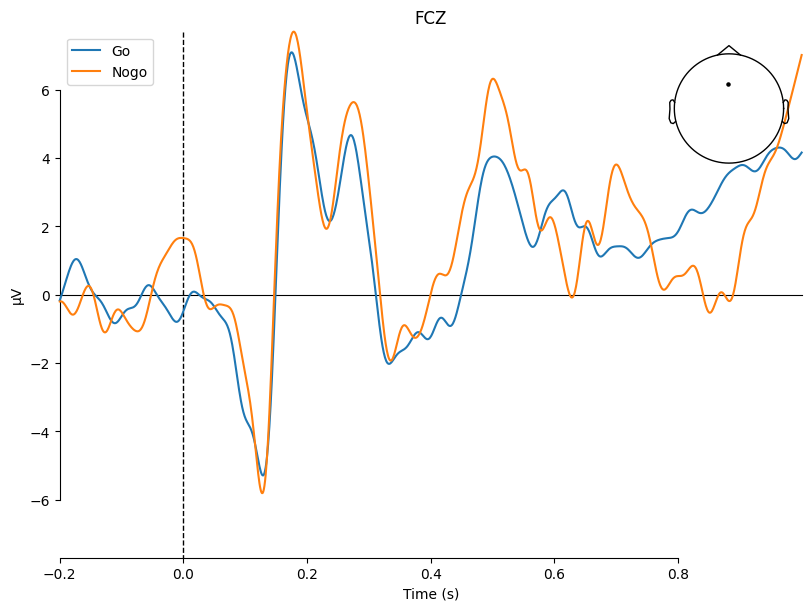

[<Figure size 800x600 with 2 Axes>]

In [2124]:
mne.viz.plot_compare_evokeds(
    {
        "Go": evoked_go,
        "Nogo": evoked_nogo
    },
    picks=["FCZ"]
)

In [2125]:
import numpy as np

# ---------- N2 ----------
n2_channels = ["FCZ"]
n2_tmin, n2_tmax = 0.300, 0.400

# ---------- P3/LPP ----------
p3_channels = ["CZ", "CPZ"]
p3_tmin, p3_tmax = 0.500, 0.700

# N2 mean amplitude
n2_go = evoked_go.copy().crop(
    n2_tmin, n2_tmax
).get_data(picks=n2_channels).mean() * 1e6

n2_nogo = evoked_nogo.copy().crop(
    n2_tmin, n2_tmax
).get_data(picks=n2_channels).mean() * 1e6

# P3/LPP mean amplitude
p3_go = evoked_go.copy().crop(
    p3_tmin, p3_tmax
).get_data(picks=p3_channels).mean() * 1e6

p3_nogo = evoked_nogo.copy().crop(
    p3_tmin, p3_tmax
).get_data(picks=p3_channels).mean() * 1e6

n2_effect = n2_nogo - n2_go
p3_effect = p3_nogo - p3_go

print("N2")
print("Go:", n2_go, "µV")
print("Nogo:", n2_nogo, "µV")
print("Nogo-Go:", n2_effect, "µV")

print("\nP3/LPP")
print("Go:", p3_go, "µV")
print("Nogo:", p3_nogo, "µV")
print("Nogo-Go:", p3_effect, "µV")

N2
Go: -1.161956461140773 µV
Nogo: -0.5835047973002089 µV
Nogo-Go: 0.578451663840564 µV

P3/LPP
Go: 5.4968735605397665 µV
Nogo: 11.39763826279561 µV
Nogo-Go: 5.900764702255843 µV


In [2126]:
n2_go_crop = evoked_go.copy().crop(n2_tmin, n2_tmax)
n2_nogo_crop = evoked_nogo.copy().crop(n2_tmin, n2_tmax)

n2_go_wave = n2_go_crop.get_data(
    picks=n2_channels
).mean(axis=0)

n2_nogo_wave = n2_nogo_crop.get_data(
    picks=n2_channels
).mean(axis=0)

n2_go_latency = (
    n2_go_crop.times[np.argmin(n2_go_wave)] * 1000
)

n2_nogo_latency = (
    n2_nogo_crop.times[np.argmin(n2_nogo_wave)] * 1000
)

In [2127]:
p3_go_crop = evoked_go.copy().crop(p3_tmin, p3_tmax)
p3_nogo_crop = evoked_nogo.copy().crop(p3_tmin, p3_tmax)

p3_go_wave = p3_go_crop.get_data(
    picks=p3_channels
).mean(axis=0)

p3_nogo_wave = p3_nogo_crop.get_data(
    picks=p3_channels
).mean(axis=0)

p3_go_latency = (
    p3_go_crop.times[np.argmax(p3_go_wave)] * 1000
)

p3_nogo_latency = (
    p3_nogo_crop.times[np.argmax(p3_nogo_wave)] * 1000
)

print("N2 latency:")
print("Go:", n2_go_latency, "ms")
print("Nogo:", n2_nogo_latency, "ms")

print("\nP3 latency:")
print("Go:", p3_go_latency, "ms")
print("Nogo:", p3_nogo_latency, "ms")

N2 latency:
Go: 333.0 ms
Nogo: 335.0 ms

P3 latency:
Go: 500.0 ms
Nogo: 502.0 ms


In [2128]:
erp_results = {
    "N2": {
        "go_amplitude_uv": n2_go,
        "nogo_amplitude_uv": n2_nogo,
        "nogo_go_effect_uv": n2_effect,
        "go_latency_ms": n2_go_latency,
        "nogo_latency_ms": n2_nogo_latency,
    },

    "P3_LPP": {
        "go_amplitude_uv": p3_go,
        "nogo_amplitude_uv": p3_nogo,
        "nogo_go_effect_uv": p3_effect,
        "go_latency_ms": p3_go_latency,
        "nogo_latency_ms": p3_nogo_latency,
    },

    "n_go_trials": len(epochs["Go"]),
    "n_nogo_trials": len(epochs["Nogo"]),
}

save_path = os.path.join(output_dir, "EF_ERP_results.npy")

np.save(
    save_path,
    erp_results,
    allow_pickle=True
)

print("Saved to:", save_path)

Saved to: H:\ASD projoect\EF\TD\2371_RF_CV_processed_numpy\EF_ERP_results.npy


In [2129]:
# brief report of numbers of oringinal epoch, average numbers of bad channels for interpolation, and numbers of epochs after ICA and interpolation
print("Number of original epochs:", len(epochs_all))
print("Number of epochs after ICA:", len(epochs_after_ica))
print("Number of epochs after interpolation:", len(epochs_interpolated))
print("Average number of bad channels for interpolation:", np.mean(remaining_bad_counts))

# save the report to a text file
report_path = os.path.join(output_dir, "preprocessing_report.txt")

with open(report_path, "w") as f:
    f.write("Number of original epochs: {}\n".format(len(epochs_all)))
    f.write("Number of epochs after ICA: {}\n".format(len(epochs_after_ica)))
    f.write("Number of epochs after interpolation: {}\n".format(len(epochs_interpolated)))
    f.write("Average number of bad channels for interpolation: {}\n".format(np.mean(remaining_bad_counts)))

Number of original epochs: 480
Number of epochs after ICA: 406
Number of epochs after interpolation: 303
Average number of bad channels for interpolation: 12.514851485148515


In [1]:
import numpy as np

d = np.load(r"F:\ASD projoect\EF\ASD\1011_RF_CV_processed_numpy\interpolated_epoch.npy",
            allow_pickle=True).item()

print(d.keys())
print("EEG:", d["eeg"].shape)
print("channels:", len(d["channels"]), d["channels"])
print("sfreq:", d["sfreq"])
print("times:", d["times"][0], d["times"][-1])

import pandas as pd
meta = pd.DataFrame(d["metadata"])
print(meta.columns)
print(meta.head(10))

dict_keys(['eeg', 'times', 'channels', 'events', 'event_id', 'metadata', 'sfreq'])
EEG: (337, 62, 1201)
channels: 62 ['FP1' 'FPZ' 'FP2' 'AF3' 'AF4' 'F7' 'F5' 'F3' 'F1' 'FZ' 'F2' 'F4' 'F6'
 'F8' 'FT7' 'FC5' 'FC3' 'FC1' 'FCZ' 'FC2' 'FC4' 'FC6' 'FT8' 'T7' 'C5' 'C3'
 'C1' 'CZ' 'C2' 'C4' 'C6' 'T8' 'M1' 'TP7' 'CP5' 'CP3' 'CP1' 'CPZ' 'CP2'
 'CP4' 'CP6' 'TP8' 'M2' 'P7' 'P5' 'P3' 'P1' 'PZ' 'P2' 'P4' 'P6' 'P8' 'PO7'
 'PO5' 'PO3' 'POZ' 'PO4' 'PO6' 'PO8' 'O1' 'OZ' 'O2']
sfreq: 1000.0
times: -0.2 1.0
Index(['stim_sample', 'stim_time_s', 'stim_code', 'go_nogo', 'emotion',
       'outcome_sample', 'outcome_time_s', 'outcome_code', 'outcome',
       'correct', 'outcome_latency_s', 'expected_pair'],
      dtype='str')
   stim_sample  stim_time_s  stim_code go_nogo   emotion  outcome_sample  \
0        51326       51.326         13      Go  Surprise         52243.0   
1        53360       53.360         13      Go  Surprise         54443.0   
2        55360       55.360         13      Go  Surprise     

In [2]:
d = np.load(
    r"F:\ASD projoect\ToM\ASD\3011a_CV_processed_numpy\interpolated_hearing_epoch.npy",
    allow_pickle=True
).item()

print(d.keys())
print("EEG:", d["eeg"].shape)
print("channels:", len(d["channels"]), d["channels"])
print("sfreq:", d["sfreq"])

meta = pd.DataFrame(d["metadata"])
print(meta.columns)
print(meta.head(10))

dict_keys(['eeg', 'times', 'channels', 'sfreq', 'metadata', 'bad_channels', 'original_epoch_idx'])
EEG: (113, 62, 2701)
channels: 62 ['FP1' 'FPZ' 'FP2' 'AF3' 'AF4' 'F7' 'F5' 'F3' 'F1' 'FZ' 'F2' 'F4' 'F6'
 'F8' 'FT7' 'FC5' 'FC3' 'FC1' 'FCZ' 'FC2' 'FC4' 'FC6' 'FT8' 'T7' 'C5' 'C3'
 'C1' 'CZ' 'C2' 'C4' 'C6' 'T8' 'M1' 'TP7' 'CP5' 'CP3' 'CP1' 'CPZ' 'CP2'
 'CP4' 'CP6' 'TP8' 'M2' 'P7' 'P5' 'P3' 'P1' 'PZ' 'P2' 'P4' 'P6' 'P8' 'PO7'
 'PO5' 'PO3' 'POZ' 'PO4' 'PO6' 'PO8' 'O1' 'OZ' 'O2']
sfreq: 1000.0
Index(['start_sample', 'audio_end_sample', 'outcome_sample', 'trigger', 'tom',
       'order', 'belief', 'outcome_code', 'correct', 'audio_duration_s',
       'response_time_s'],
      dtype='str')
   start_sample  audio_end_sample  outcome_sample  trigger        tom   order  \
0         47956           52958.0         56987.0       71  affective   first   
1         59322           64325.0         68603.0       31  cognitive   first   
2         92123           98625.0        103340.0       32  cognit